# Multimodal Emotion Recognition 

In [1]:
import os,sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import librosa
import IPython.display
import seaborn as sns 
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import f1_score,precision_score,recall_score,confusion_matrix
import re 

SEED = 207

np.random.seed(SEED)
torch.manual_seed(SEED)
device = 'cuda' if torch.cuda.is_available() else 'cpu'           

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("uwrfkaggler/ravdess-emotional-speech-audio")

# print("Path to dataset files:", path)

## 1. Task Defintion
Design a deep learning model that classifies human emotions using both :
- Audio data 
- Text transcripts

Target labels:
- Emotion
- Gender (females have higher pitch than male and therefore would affect the features of audio being used)

## 2. Data Loading

In [3]:
base_path = path 
dir_list = os.listdir(base_path)

# Get a list of all the audio files to vectorise their emotion and gender extraction and store them in a dataframe
actor_paths = [os.path.join(base_path,actor,f) for actor in dir_list for f in os.listdir(os.path.join(base_path,actor))]

# Datafram to store all the data with its features
df = pd.DataFrame({'path' : actor_paths})

# Add labels
# get the file name -> remove the extension .wav -> get the identifiers via expand for columns 
parts = df['path'].str.split(os.sep).str[-1].str.split('.').str[0].str.split('-',expand=True)  
                      

emotion_map = {1:'neutral', 2:'calm', 3:'happy', 4:'sad',5:'angry', 6:'fearful', 7:'disgust', 8:'surprise'}
emotion_class = [emotion_map[i] for i in emotion_map]
# label each file as "gender_emotion"
df['actor'] = parts[6].astype(int)
df['emotion'] = parts[2].astype(int).map(emotion_map)
df['gender'] = (parts[6].astype(int)%2)
df['label'] = parts[2].astype(int) -1 
N_CLASSES = df['emotion'].nunique()
print(f"Total classes : {N_CLASSES}")
print(df['emotion'].value_counts())

Total classes : 8
emotion
calm        192
happy       192
sad         192
angry       192
fearful     192
disgust     192
surprise    192
neutral      96
Name: count, dtype: int64


## 2.1 Dataset Characteristics

- Class balance : 
  - `neutral` onlyu has 48 clips per gender (96 total) vs 96 per gender for all other emotions as no 'strong' intensity for neutral is present.
  - With 8 classes the imbalance is only in neutral -> use class weights
- We hav ~90 clips per class on average and only two senetence spoken for all emotions
  -  so text branch will carry very less signal by itself
  -  and very less clips are available per class as well

- All clips are roughly 3-4 seconds

Emotion : calm
Original sr : 48000 Hz


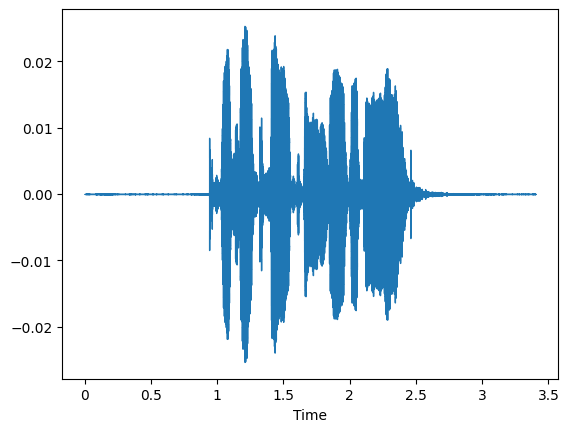

In [4]:
# Confirm the files and paths are correct and check audio
test_path = df['path'].sample(1).values[0]
test_audio,sample_sr = librosa.load(test_path,sr=None)
test_emotion = df.loc[df['path']==test_path,'emotion'].values[0]

print(f"Emotion : {test_emotion}")
print(f"Original sr : {sample_sr} Hz")
librosa.display.waveshow(test_audio,sr=sample_sr)
plt.show()
IPython.display.Audio(test_path)

## 3.1 Audio preprocessing 

Converting raw waveform into Mel-Spectrogram 

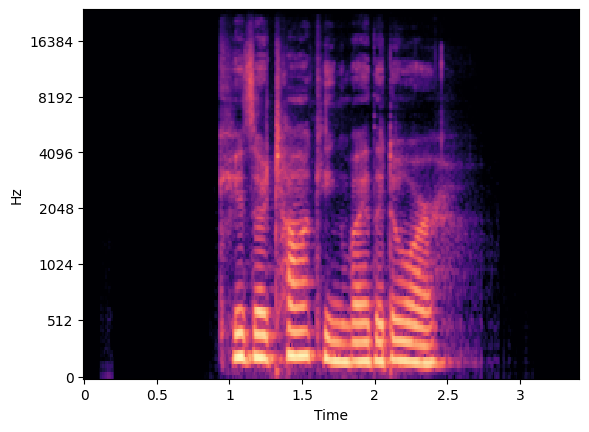

In [5]:
# Normal linear spectrogram
test_spec = np.abs(librosa.stft(test_audio))
# librosa.display.specshow(test_spec,sr=sample_sr,y_axis='linear',x_axis='time')
# plt.show()
# Mel spectrogram
test_mel_spec = librosa.feature.melspectrogram(y=test_audio,sr=sample_sr)
test_meldb_spec = librosa.power_to_db(test_mel_spec)
librosa.display.specshow(test_meldb_spec,sr=sample_sr,x_axis='time',y_axis='mel')
plt.show()


In [ ]:
SR = 22050
DURATION = 3
N_MELS = 64
N_FFT = 2048
HOP_LENGTH=512  
LEN = int(SR*DURATION)  
# STFT slides a window every hop_length samples, so total frames = LEN/HOP_LEN ~ 130 here
# so output size is (64,130)
def mel_conv(path):
    y, _ = librosa.load(path,sr=SR)         # load + resample

    y,_ = librosa.effects.trim(y,top_db=60) # trim 

    if len(y) < LEN:                        # fix length
        y = np.pad(y,(0,LEN-len(y)))
    else:
        y = y[:LEN]
    # mel spectrogram
    m = librosa.feature.melspectrogram(y=y,sr=SR,n_mels=N_MELS,n_fft=N_FFT,hop_length=HOP_LENGTH)
    # decibel
    m_db = librosa.power_to_db(m ,ref=1.0)
    # standardize
    m_db = (m_db-m_db.mean()) / (m_db.std() + 1e-6)
    return m_db      


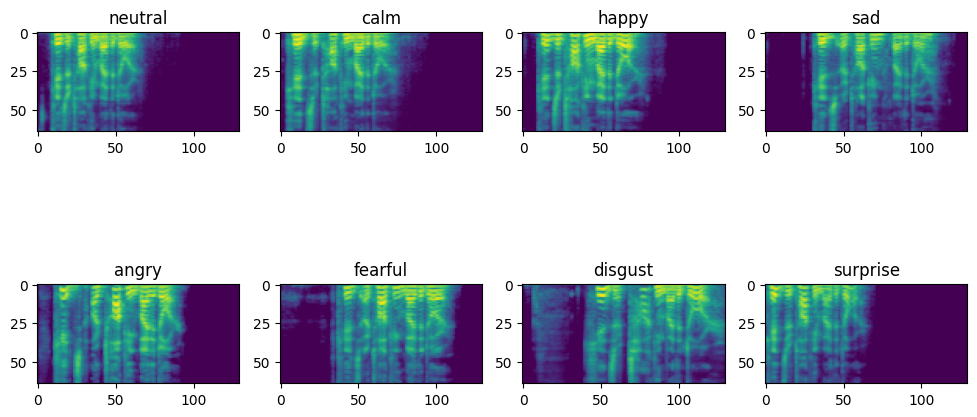

In [7]:
fig,ax = plt.subplots(2,4,figsize=(12,6))
ax = ax.flatten()
for i,emotion in enumerate(df['emotion'].unique()):
    path = df[df['emotion'] == emotion]['path'].values[0]
    mel = mel_conv(path)
    ax[i].imshow(mel)
    ax[i].set_title(emotion)
plt.show()

# 3.2 Train/Val/Test split
- Formula - $\frac{\text{tot samples}}{\text{n classes * count per class}}$
- So neutral with fewer clips gets penalised more heavily when misclassified

In [8]:
# 80/10/10 split, staratified on label so class proprotions are preserved in each split
# this is required because neutral has less data points
train_df,temp_df = train_test_split(df,test_size=0.2,stratify=df['label'],random_state=SEED)
val_df,test_df = train_test_split(temp_df,test_size=0.5,stratify=temp_df['label'],random_state=SEED)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)
print(f'Train: {len(train_df)}  Val: {len(val_df)}  Test: {len(test_df)}')

Train: 1152  Val: 144  Test: 144


In [9]:
class_weights = compute_class_weight(class_weight='balanced',classes=np.arange(N_CLASSES),y=train_df['label'].values)
class_weights = torch.tensor(class_weights).to(device)
print(class_weights)

tensor([1.8701, 0.9412, 0.9351, 0.9412, 0.9351, 0.9351, 0.9351, 0.9412],
       device='cuda:0', dtype=torch.float64)


## 4. CNN
The preprocessing fucntion outputs shape `(64,130)`, first the CNN expects a format of (batch,channel,height,width), so with `unsqueeze(0)` we need to specify it has 1 channel
 



In [10]:
class AudioDataset(Dataset):
    def __init__(self,df):
        self.paths = df['path'].values
        self.labels = torch.tensor(df['label'].values, dtype=torch.long)
        self.genders = torch.tensor(df['gender'].values, dtype=torch.long)
    def __len__(self):
        return len(self.paths)
    
    def __getitem__(self, index):

        mel = mel_conv(self.paths[index])
        # (64,130) -> (1,64,130)
        x = torch.tensor(mel,dtype=torch.float).unsqueeze(0)
        return x,self.genders[index],self.labels[index]
    
audio_train_loader = DataLoader(AudioDataset(train_df),batch_size=32, shuffle=True)
audio_val_loader = DataLoader(AudioDataset(val_df),batch_size=32, shuffle=False)
audio_test_loader  = DataLoader(AudioDataset(test_df),batch_size=32, shuffle=False)

x,g,y = next(iter(audio_train_loader))
print('Spectrogram batch:', x.shape) 
print('Gender batch:', g.shape) 
print('Label batch:', y.shape)

Spectrogram batch: torch.Size([32, 1, 64, 130])
Gender batch: torch.Size([32])
Label batch: torch.Size([32])


### CNN Architecture 
Entire thought process and architecture in `report.md`
   

In [ ]:
class AudioCNN(nn.Module):
    def __init__(self,n_classes=8):
        super().__init__()

        self.frequency_block = nn.Sequential(
            nn.Conv2d(1,16,kernel_size=(5,1),padding=(2,0))
            ,nn.BatchNorm2d(16), nn.ReLU(),
            nn.Conv2d(16,32,kernel_size=(5,1),padding=(2,0))
            ,nn.BatchNorm2d(32),nn.ReLU(),              # (32,64,130)
        )

        self.time_block = nn.Sequential(
            nn.Conv2d(32,32,kernel_size=(1,9),padding=(0,4)),
            nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32,64,kernel_size=(1,9),padding=(0,4)),
            nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(kernel_size=(2,4),stride=(2,4)),  # (64,32,32)
        )

        # outputs 128 values - first 64 are per-channel scale, last 64 are per-channel shift
        self.gender_emb  = nn.Embedding(2,8)
        self.gender_film = nn.Linear(8,128)  # 64 gamma + 64 beta
        # AdaptiveAvgPool2d takes the final shape we want as the argument
        self.cross_block = nn.Sequential(
            nn.Conv2d(64,64,kernel_size=3,padding=1),
            nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64,128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2,2),
            nn.Conv2d(128,128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(),
            nn.AdaptiveAvgPool2d((2,2)),  # (128,2,2) -> 512
        )

        self.bottleneck = nn.Sequential(
            nn.Flatten(),           # 512
            nn.Linear(512,128),
            nn.BatchNorm1d(128), nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128,64),
            nn.ReLU(),
        )
        self.classifier = nn.Linear(64,n_classes)

        self.train_losses = []
        self.val_losses   = []
    
    def forward(self,x,gender):

        feat = self.frequency_block(x)
        feat = self.time_block(feat)
        g = self.gender_emb(gender)             # (n,8)
        film = self.gender_film(g)              # (n,128)
        gamma,beta = film.chunk(2,dim=1)        # (n,64) (n,64)
        gamma = gamma.unsqueeze(-1).unsqueeze(-1) # (n,64,1,1)
        beta = beta.unsqueeze(-1).unsqueeze(-1)
        feat = gamma*feat + beta
        feat = self.cross_block(feat)
        return self.classifier(self.bottleneck(feat))
    
    def fit(self,train_loader,val_loader,
            epochs=30,
            lr=1e-3,
            optim = torch.optim.Adam,
            class_weights= None,
            device=device,
            path='best_cnn_weight.pt',      # path to save best weights according to validation
            **kwargs                        # optmiser specific args like weight decay
            ):
        self.to(device)

        optimiser = optim(self.parameters(),lr=lr,**kwargs)
        criterion = nn.CrossEntropyLoss(weight=class_weights)
        best_val = np.inf

        for epoch in range(epochs):
            self.train()
            epoch_loss = 0.0
            for x,gender,y in train_loader:
                x = x.to(device)
                gender = gender.to(device)
                y = y.to(device)
                optimiser.zero_grad()
                loss = criterion(self.forward(x,gender), y)
                loss.backward()
                optimiser.step()
                epoch_loss += loss.item()
            epoch_loss /= len(train_loader)
            self.train_losses.append(epoch_loss)
            
            self.eval()
            val_loss = 0.0
            with torch.no_grad():
                for x,gender,y in val_loader:
                    x = x.to(device)
                    gender = gender.to(device)
                    y = y.to(device)
                    out = self(x,gender)
                    val_loss += criterion(out,y).item()
            val_loss /= len(val_loader)
            self.val_losses.append(val_loss)

            if val_loss < best_val:
                best_val = val_loss
                torch.save(self.state_dict(),path)

            if (epoch + 1) % 5 == 0:
                print(f'Epoch {epoch+1:3d} | Train: {epoch_loss:.4f} | Val: {val_loss:.4f}')
    @torch.no_grad
    def predict(self, loader, device=device):
        self.eval().to(device)
        probs_list, labels_list = [], []
        for x, gender, y in loader:
            p = torch.softmax(self.forward(x.to(device), gender.to(device)), dim=1)
            probs_list.append(p.cpu().numpy())
            labels_list.append(y.numpy())
        return np.concatenate(probs_list), np.concatenate(labels_list)

In [27]:
audio_model = AudioCNN(N_CLASSES)
EPOCHS = 100
LR = 5e-4
audio_model.fit(audio_train_loader,audio_val_loader,
        epochs=EPOCHS,
        lr=LR,
        class_weights=class_weights.float(),
        device=device,
        path='best_cnn_weight.pt',
        weight_decay=1e-4
)

Epoch   5 | Train: 1.7649 | Val: 1.7940
Epoch  10 | Train: 1.3362 | Val: 1.8988
Epoch  15 | Train: 1.0067 | Val: 1.2757
Epoch  20 | Train: 0.7514 | Val: 1.4203
Epoch  25 | Train: 0.5029 | Val: 0.9443
Epoch  30 | Train: 0.3675 | Val: 0.9081
Epoch  35 | Train: 0.2036 | Val: 2.2673
Epoch  40 | Train: 0.1133 | Val: 1.0298
Epoch  45 | Train: 0.1824 | Val: 1.0762
Epoch  50 | Train: 0.0849 | Val: 1.2375
Epoch  55 | Train: 0.1124 | Val: 1.1652
Epoch  60 | Train: 0.1019 | Val: 1.4340
Epoch  65 | Train: 0.0990 | Val: 1.3558
Epoch  70 | Train: 0.0392 | Val: 0.9711
Epoch  75 | Train: 0.0272 | Val: 1.3267
Epoch  80 | Train: 0.0349 | Val: 1.6892
Epoch  85 | Train: 0.0254 | Val: 1.4342
Epoch  90 | Train: 0.1224 | Val: 1.7437
Epoch  95 | Train: 0.0276 | Val: 1.2135
Epoch 100 | Train: 0.0094 | Val: 0.9152


In [42]:

audio_model.load_state_dict(torch.load('best_cnn_weight.pt',weights_only=True))
audio_probs_test, true = audio_model.predict(audio_test_loader)

audio_preds = audio_probs_test.argmax(axis=1)
cnn_acc = (audio_preds == true).mean()
print(f"\nCNN - Test Accuracy : {cnn_acc:.4f}")


CNN - Test Accuracy : 0.7847


## 5. RNN
The audio clips are transcribed using Whisper then classified with an Embedding + GRU model. 
* RAVDESS only contains two sentences spoken across all 8 emotions. The text containts zero emtion context and Whisper will transcribe almost identically regardless of emotion. 
* This branch will perform close to random and no choices can change that as its a data problem. So I didnt put much thought into architecture design compared to CNN.
## 5.1 Transcribing
Used Whisper to transcribe the clips into text as told in task.
Whisper is an encoder-decoder transformer trained on 680k hours of speech.
- Load at mono 16kHz because thats waht Whisper was trained on.
- Use the tiny model  - 39M parameters

Save the transcripts to run the model only once since this is an expensive step

In [29]:
TRANSCRIPT = 'transcripts.csv'

# loading transcriptions if already exists
if os.path.exists(TRANSCRIPT):
    tr_df = pd.read_csv(TRANSCRIPT)
else:
    import whisper
    # load the tiny model
    tr_model = whisper.load_model('tiny')
    # list for storing results of the transcriptions 
    results = []
    # iterate over all rows
    for i,row in df.iterrows():
        # extract the audio as a numpy array  using the path and sr 
        audio,_ = librosa.load(row['path'],sr=16000,mono=True)
        # transcribe
        out = tr_model.transcribe(audio,language='en')
        # store as a dictionary path and its transcript - remove leading trailing white spaces
        results.append({'path':row['path'],'transcript':out['text'].strip()})
    # convert to dataframe
    tr_df = pd.DataFrame(results)
    # save as csv, set index false , when loading again index added naturally
    tr_df.to_csv(TRANSCRIPT,index=False)

# assuming transcripts exists in csv so need to create the same map as in results again
tr_map = tr_df.set_index('path')['transcript'].to_dict()
# create the transcript column and map it 
df['transcript'] = df['path'].map(tr_map)
print(df['transcript'].head())

0    Kids are talking by the door.
1    Kids are talking by the door.
2    Dogs are sitting by the door.
3    Dogs are sitting by the door.
4    Kids are talking by the door.
Name: transcript, dtype: str


## 5.2 Tokenisation

    

In [65]:
MAX_LEN = 15

# function for lower case and removing punctuations and splitting
def standardize_token(text):
    # conver to lower-case -> remove everything except letters and space -> split at space
    return re.sub(r'[^a-z ]','',text.lower()).split()

# create vocabulary dictionary using only words from the transcripts of train data points
vocab = {'<PAD>':0,'<UNK>':1 }
train_tokens = [token for t in df.loc[train_df.index,'transcript'] for token in standardize_token(t)]
# 0,1 reserved for special tokens
vocab.update({word:i+2 for i,word in enumerate(set(train_tokens))})
VOCAB_SIZE = len(vocab)
# encode all the text 
def encode(text):
    # get the corresponding integer for each word
    code = [vocab.get(i,1) for i in standardize_token(text)]
    # padding
    code = code[:MAX_LEN] + [0]*max(0,MAX_LEN-len(code))
    return code
# add the encodings as a column
df['encoded'] = df['transcript'].apply(encode)
# check 
print(df.sample(1).values[0][4:])

[4 'Kids are talking by the door.'
 list([39, 104, 11, 24, 78, 19, 0, 0, 0, 0, 0, 0, 0, 0, 0])]


## 5.3 GRU


In [31]:
class TextDataset(Dataset):
    def __init__(self,df):
        self.sequences = torch.tensor(df['encoded'].to_list(), dtype=torch.long)
        self.labels = torch.tensor(df['label'].values,dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, index):
        return self.sequences[index],self.labels[index]

# add the encodings to  train val test df
encoded_map = df.set_index('path')['encoded'].to_dict()
for d in [train_df,val_df,test_df]:
    d['encoded'] = d['path'].map(encoded_map)

text_train_loader = DataLoader(TextDataset(train_df), batch_size=32, shuffle=True)
text_val_loader   = DataLoader(TextDataset(val_df),   batch_size=32, shuffle=False)
text_test_loader  = DataLoader(TextDataset(test_df),  batch_size=32, shuffle=False)

In [32]:
class TextGRU(nn.Module):
    def __init__(self,input_dim,emb_dim=32,hidden_dim=64,n_classes=8):
        super().__init__()
        # create a embedding table to represent each of the tokens as emb_dim dimensional vector
        # <PAD> token should give a 0 vector to not affect gradients
        self.embedding = nn.Embedding(input_dim,embedding_dim=emb_dim,padding_idx=0)

        # now each encoded sentence is loaded as a sequence and passed through a GRU layer
        self.gru = nn.GRU(emb_dim,hidden_dim,batch_first=True)
                
        self.bottleneck = nn.Sequential(nn.Linear(hidden_dim,64),nn.ReLU())
        self.classifier = nn.Linear(64,n_classes)
        self.train_losses = []
        self.val_losses = []

    def forward(self,txt):
        emb = self.embedding(txt)   # (n,15,32)
        out,h_t = self.gru(emb)     # (1,n,64) -> final hidden state
        h = h_t.squeeze(0)
        emb_out = self.bottleneck(h)
        return self.classifier(emb_out)
    
    def fit(self,train_loader,val_loader,
            epochs=30,
            lr=1e-3,
            class_weights=None,
            device=device,
            ):
        
        self.to(device)
        optimiser = torch.optim.Adam(self.parameters(),lr=lr,weight_decay=1e-4)
        criterion = nn.CrossEntropyLoss(weight=class_weights)
        best_val = np.inf
        
        for epoch in range(epochs):
            self.train()
            epoch_loss = 0.0

            for x,y in train_loader:
                x = x.to(device)
                y = y.to(device)

                optimiser.zero_grad()
                loss = criterion(self.forward(x),y)
                loss.backward()
                optimiser.step()

                epoch_loss +=loss.item()
            epoch_loss /= len(train_loader)
            self.train_losses.append(epoch_loss)

            self.eval()
            val_loss = 0.0
            with torch.no_grad():
                for x,y in val_loader:
                    x = x.to(device)
                    y = y.to(device)
                    val_loss += criterion(self.forward(x),y).item()
            val_loss /= len(val_loader)
            self.val_losses.append(val_loss)

            if val_loss < best_val:
                best_val = val_loss
                torch.save(self.state_dict(),'best_rnn_weights.pt')
            if (epoch+1)%5 ==0:
                print(f'Epoch {epoch+1:3d} | Train: {epoch_loss:.4f} | Val: {val_loss:.4f}')
    @torch.no_grad()
    def predict(self, loader, device=device):
        self.eval().to(device)
        probs_list, labels_list = [], []
        for x,y in loader:
            p = torch.softmax(self.forward(x.to(device)), dim=1)
            probs_list.append(p.cpu().numpy())
            labels_list.append(y.numpy())
        return np.concatenate(probs_list), np.concatenate(labels_list)

In [33]:
text_model = TextGRU(VOCAB_SIZE,n_classes=N_CLASSES)
text_model.fit(text_train_loader,text_val_loader,epochs=EPOCHS,lr=LR,class_weights=class_weights.float(),device=device)
text_model.load_state_dict(torch.load('best_rnn_weights.pt',weights_only=True))
text_probs_test, true_vals = text_model.predict(text_test_loader,device=device)

text_preds = text_probs_test.argmax(axis=1)
rnn_acc = (text_preds == true_vals).mean()
print(f'\nText GRU - Test Accuracy: {rnn_acc:.4f}')


Epoch   5 | Train: 2.0801 | Val: 2.0790
Epoch  10 | Train: 2.0798 | Val: 2.0790
Epoch  15 | Train: 2.0799 | Val: 2.0791
Epoch  20 | Train: 2.0799 | Val: 2.0792
Epoch  25 | Train: 2.0797 | Val: 2.0791
Epoch  30 | Train: 2.0802 | Val: 2.0791
Epoch  35 | Train: 2.0797 | Val: 2.0791
Epoch  40 | Train: 2.0798 | Val: 2.0791
Epoch  45 | Train: 2.0799 | Val: 2.0791
Epoch  50 | Train: 2.0798 | Val: 2.0790
Epoch  55 | Train: 2.0798 | Val: 2.0790
Epoch  60 | Train: 2.0798 | Val: 2.0791
Epoch  65 | Train: 2.0800 | Val: 2.0792
Epoch  70 | Train: 2.0797 | Val: 2.0791
Epoch  75 | Train: 2.0798 | Val: 2.0791
Epoch  80 | Train: 2.0797 | Val: 2.0792
Epoch  85 | Train: 2.0798 | Val: 2.0791
Epoch  90 | Train: 2.0797 | Val: 2.0793
Epoch  95 | Train: 2.0797 | Val: 2.0792
Epoch 100 | Train: 2.0797 | Val: 2.0790

Text GRU - Test Accuracy: 0.1389


## 6 Fusion

### 6.1 Late Fusion



In [34]:
audio_preds = audio_probs_test.argmax(1)
text_preds  = text_probs_test.argmax(1)
avg_probs   = (audio_probs_test + text_probs_test)/2
wt_probs    = 0.7*audio_probs_test + 0.3*text_probs_test
print(f'Late fusion (avg): {(avg_probs.argmax(1) == true).mean():.4f}')
print(f'Late fusion (0.7/0.3): {(wt_probs.argmax(1) == true).mean():.4f}')

Late fusion (avg): 0.7847
Late fusion (0.7/0.3): 0.7847


## 7. Results 
Accuracies

In [43]:
print(f"Audio CNN : {cnn_acc:.4f}")
print(f"Text GRU : {rnn_acc:.4f}")
print(f'Late fusion (avg): {(avg_probs.argmax(1) == true).mean():.4f}')
print(f"Late fusion (weighted): {(wt_probs.argmax(1) == true).mean():.4f}")

Audio CNN : 0.7847
Text GRU : 0.1389
Late fusion (avg): 0.7847
Late fusion (weighted): 0.7847


### Loss Plots

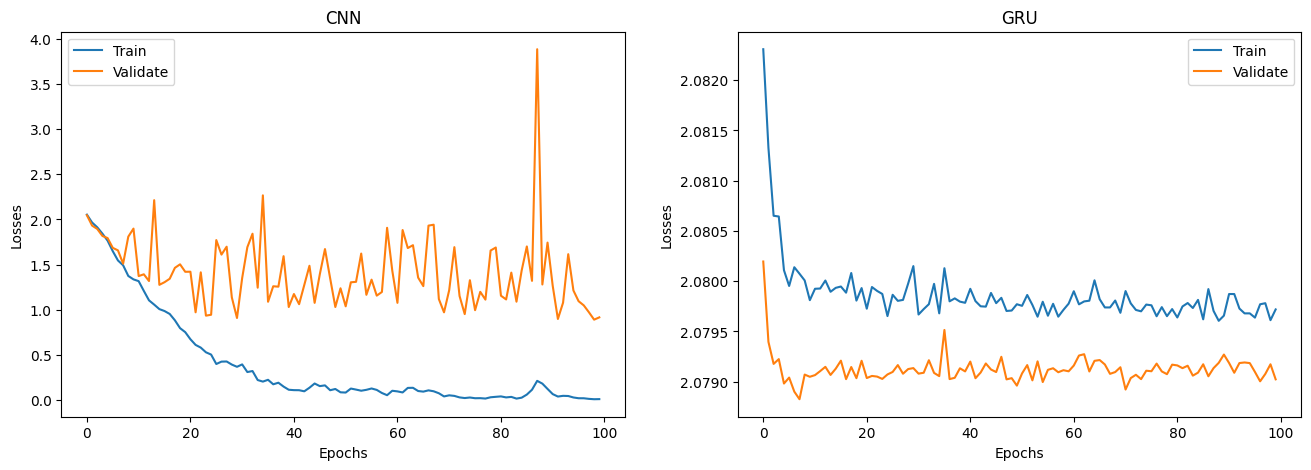

In [61]:
fig,ax = plt.subplots(1,2,figsize=(16,5))
for i,m in [(0,audio_model),(1,text_model)]:
    ax[i].plot(np.arange(EPOCHS),m.train_losses,label='Train')
    ax[i].plot(np.arange(EPOCHS),m.val_losses,label='Validate')
    ax[i].set_xlabel('Epochs')
    ax[i].set_ylabel('Losses')
    ax[i].set_title(f"{'CNN' if i==0 else 'GRU'}")
    ax[i].legend()


### Precision, Recall, f1 score

In [37]:
rows = []
for i,m in [(audio_probs_test,"CNN"),(text_probs_test,"GRU"),(avg_probs,"Fusion(avg)"),(wt_probs,"Fusion(weighted)")]:

    pred = i.argmax(1)
    p = precision_score(true,pred,average=None,zero_division=0)
    r = recall_score(true,pred,average=None)
    f = f1_score(true,pred,average=None)

    for cls,pc,rc,fc in zip(emotion_class,p,r,f):
        rows.append([m,cls,pc,rc,fc])
results_df = pd.DataFrame(rows,columns=["Model","Class","Precision","Recall","F1"])
print(results_df.pivot(index="Class",columns="Model"))

         Precision                                           Recall  \
Model          CNN Fusion(avg) Fusion(weighted)       GRU       CNN   
Class                                                                 
angry     0.812500    0.812500         0.812500  0.000000  0.684211   
calm      0.888889    0.888889         0.888889  0.000000  0.842105   
disgust   0.695652    0.695652         0.695652  0.000000  0.842105   
fearful   0.714286    0.714286         0.714286  0.000000  0.789474   
happy     0.933333    0.933333         0.933333  0.000000  0.736842   
neutral   0.666667    0.666667         0.666667  0.000000  0.666667   
sad       0.714286    0.714286         0.714286  0.000000  0.750000   
surprise  0.857143    0.857143         0.857143  0.138889  0.900000   

                                                  F1              \
Model    Fusion(avg) Fusion(weighted)  GRU       CNN Fusion(avg)   
Class                                                              
angry       0.

In [38]:
for i,m in [(audio_probs_test,"CNN"),(text_probs_test,"GRU"),(avg_probs,"Fusion(avg)"),(wt_probs,"Fusion(weighted)")]:

    pred = i.argmax(1)
    p = precision_score(true,pred,average="weighted",zero_division=0)
    print(f"{m} : {p:.4f}")

CNN : 0.7936
GRU : 0.0193
Fusion(avg) : 0.7936
Fusion(weighted) : 0.7936


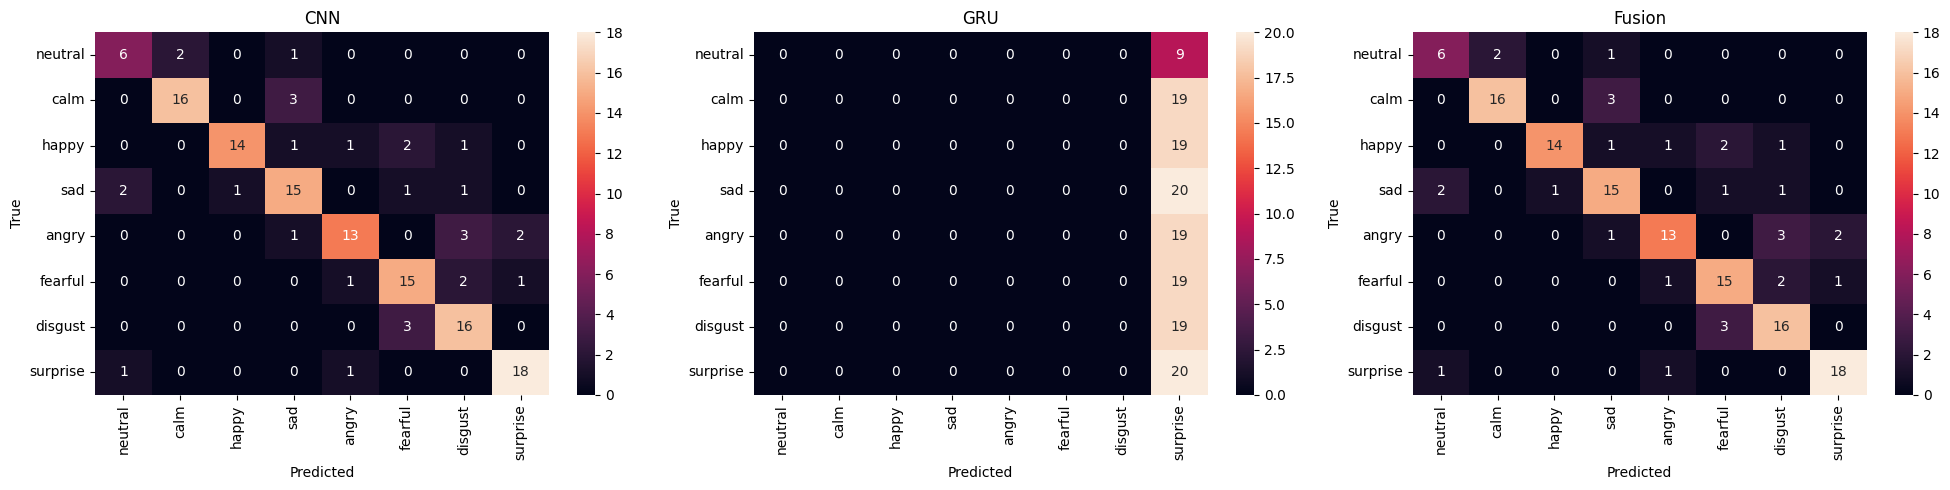

In [39]:
fig,ax = plt.subplots(1,3,figsize=(20,5))

for i,(t,m) in enumerate([("CNN",audio_probs_test),("GRU",text_probs_test),("Fusion",avg_probs)]):
    sns.heatmap(confusion_matrix(true,m.argmax(1)),annot=True,xticklabels=emotion_class,yticklabels=emotion_class,ax=ax[i])
    ax[i].set_xlabel('Predicted')
    ax[i].set_ylabel('True')
    ax[i].set_title(t)
plt.tight_layout()


## Testing with leaving one actor out completely

In [40]:
LEAVE_ACTOR = 24
test_df_leave = df[df['actor'] == LEAVE_ACTOR].reset_index(drop=True)
trainval_leave = df[df['actor'] != LEAVE_ACTOR].reset_index(drop=True)

train_df_leave, val_df_leave = train_test_split(trainval_leave, test_size=0.1,stratify=trainval_leave['label'], random_state=SEED)
train_df_leave = train_df_leave.reset_index(drop=True)
val_df_leave   = val_df_leave.reset_index(drop=True)

weights_leave = compute_class_weight(class_weight='balanced',classes=np.arange(N_CLASSES),y=train_df_leave['label'].values)
weights_leave = torch.tensor(weights_leave, dtype=torch.float).to(device)

tr_leave_loader = DataLoader(AudioDataset(train_df_leave),batch_size=32, shuffle=True)
val_leave_loader = DataLoader(AudioDataset(val_df_leave), batch_size=32,shuffle=False)
test_leave_loader = DataLoader(AudioDataset(test_df_leave), batch_size=32,shuffle=False)

loao_model = AudioCNN(N_CLASSES)
loao_model.fit(tr_leave_loader, val_leave_loader,epochs=EPOCHS, lr=LR,class_weights=weights_leave,device=device,path='best_loao.pt')
loao_model.load_state_dict(torch.load('best_loao.pt',weights_only=True))

loao_probs,loao_true=loao_model.predict(test_leave_loader)

loao_preds =loao_probs.argmax(1)
print(f'Leave one actor out (actor {LEAVE_ACTOR}) accuracy : {(loao_preds == loao_true).mean():.4f}')

Epoch   5 | Train: 1.7039 | Val: 1.6990
Epoch  10 | Train: 1.3122 | Val: 1.4034
Epoch  15 | Train: 0.9537 | Val: 1.0628
Epoch  20 | Train: 0.7795 | Val: 2.8665
Epoch  25 | Train: 0.5765 | Val: 1.0935
Epoch  30 | Train: 0.4307 | Val: 1.2574
Epoch  35 | Train: 0.3087 | Val: 1.8466
Epoch  40 | Train: 0.2445 | Val: 0.9806
Epoch  45 | Train: 0.1533 | Val: 0.7689
Epoch  50 | Train: 0.1125 | Val: 1.2014
Epoch  55 | Train: 0.1439 | Val: 1.9977
Epoch  60 | Train: 0.0285 | Val: 0.8033
Epoch  65 | Train: 0.0627 | Val: 2.1264
Epoch  70 | Train: 0.1606 | Val: 1.9540
Epoch  75 | Train: 0.0826 | Val: 1.2809
Epoch  80 | Train: 0.0606 | Val: 1.0396
Epoch  85 | Train: 0.0347 | Val: 1.1677
Epoch  90 | Train: 0.0313 | Val: 1.0379
Epoch  95 | Train: 0.0184 | Val: 1.0025
Epoch 100 | Train: 0.1177 | Val: 1.4582
Leave one actor out (actor 24) accuracy : 0.5667


## Testing with augmented data

In [58]:
def mel_conv_augmented(path):

    y,_ = librosa.load(path,sr=SR)
    y,_ = librosa.effects.trim(y,top_db=60)

    if len(y) < LEN:
        y = np.pad(y,(0,LEN-len(y)))
    else:
        y = y[:LEN]
    
    pitch_shift = np.random.choice([-1,-0.5,0,0.5,1])
    y = librosa.effects.pitch_shift(y,sr=SR,n_steps=pitch_shift)

    noise = np.random.randn(len(y)) * np.random.choice([5e-4,0])
    y+= noise

    m = librosa.feature.melspectrogram(y=y,sr=SR,n_mels=N_MELS,n_fft=N_FFT,hop_length=HOP_LENGTH)
    m_db = librosa.power_to_db(m,ref=1.0)
    m_db = (m_db-np.mean(m_db)) / (m_db.std() + 1e-6)
    return m_db

class AugmentedAudioDataset(Dataset):
    def __init__(self,df):
        self.paths = df['path'].values
        self.labels = torch.tensor(df['label'].values, dtype=torch.long)
        self.genders = torch.tensor(df['gender'].values, dtype=torch.long)
    
    def __len__(self):
        return len(self.paths)
    
    def __getitem__(self, index):
        mel = mel_conv_augmented(self.paths[index])
        x = torch.tensor(mel,dtype=torch.float).unsqueeze(0)
        return x,self.genders[index],self.labels[index]

aug_test_loader = DataLoader(AugmentedAudioDataset(test_df), batch_size=32, shuffle=False)
audio_model.load_state_dict(torch.load('best_cnn_weight.pt',weights_only=True))
aug_probs,aug_true = audio_model.predict(aug_test_loader)
aug_preds = aug_probs.argmax(1)
aug_acc = (aug_preds == aug_true).mean()
print(f'Clean test accuracy : {cnn_acc:.4f}')
print(f'Augmented test accuracy : {aug_acc:.4f}')
print(f'Accuracy drop : {cnn_acc - aug_acc:.4f}')


Clean test accuracy : 0.7847
Augmented test accuracy : 0.5903
Accuracy drop : 0.1944


In [ ]:
# for the architecture chart required in the report 
from torchinfo import summary
dum_x = torch.zeros(1,1,64,130).to(device)
dum_y = torch.zeros(1,dtype=torch.long).to(device)
summary(audio_model,input_data=[dum_x,dum_y])

Layer (type:depth-idx)                   Output Shape              Param #
AudioCNN                                 [1, 8]                    --
├─Sequential: 1-1                        [1, 32, 64, 130]          --
│    └─Conv2d: 2-1                       [1, 16, 64, 130]          96
│    └─BatchNorm2d: 2-2                  [1, 16, 64, 130]          32
│    └─ReLU: 2-3                         [1, 16, 64, 130]          --
│    └─Conv2d: 2-4                       [1, 32, 64, 130]          2,592
│    └─BatchNorm2d: 2-5                  [1, 32, 64, 130]          64
│    └─ReLU: 2-6                         [1, 32, 64, 130]          --
├─Sequential: 1-2                        [1, 64, 32, 32]           --
│    └─Conv2d: 2-7                       [1, 32, 64, 130]          9,248
│    └─BatchNorm2d: 2-8                  [1, 32, 64, 130]          64
│    └─ReLU: 2-9                         [1, 32, 64, 130]          --
│    └─Conv2d: 2-10                      [1, 64, 64, 130]          18,496
│    